In [83]:
!rm -rf sample_data/

In [84]:
!pip install yahoo_fin requests-html

In [85]:
import os
import requests
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [86]:
ticker = "TSLA"
end_date = datetime.now()
start_date = end_date - timedelta(days=5380) # 5380 days since June 29, 2010

In [87]:
tesla_data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
print('\n')
print(tesla_data.head())
print("\nActual columns in dataframe:")
print(tesla_data.columns.tolist())

[*********************100%***********************]  1 of 1 completed



Price          Close      High       Low      Open     Volume
Ticker          TSLA      TSLA      TSLA      TSLA       TSLA
Date                                                         
2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500
2010-07-07  1.053333  1.108667  0.998667  1.093333  103825500

Actual columns in dataframe:
[('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]


In [88]:
tesla_data['Daily_Return'] = tesla_data['Close'].pct_change()
tesla_data['MA50'] = tesla_data['Close'].rolling(window=50).mean()
tesla_data['MA200'] = tesla_data['Close'].rolling(window=200).mean()
print(f'{tesla_data.tail()}')

Price            Close        High         Low        Open     Volume  \
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA   
Date                                                                    
2025-03-17  238.009995  245.399994  232.800003  245.059998  111900600   
2025-03-18  225.309998  230.100006  222.279999  228.160004  111477600   
2025-03-19  235.860001  241.410004  229.199997  231.610001  111993800   
2025-03-20  236.259995  238.000000  230.050003  233.350006   99028300   
2025-03-21  248.710007  249.520004  234.550003  234.990005  132211300   

Price      Daily_Return        MA50      MA200  
Ticker                                          
Date                                            
2025-03-17    -0.047884  348.304599  282.98555  
2025-03-18    -0.053359  345.225199  283.23115  
2025-03-19     0.046824  341.733599  283.51650  
2025-03-20     0.001696  338.237799  283.80740  
2025-03-21     0.052696  335.324799  284.16950  


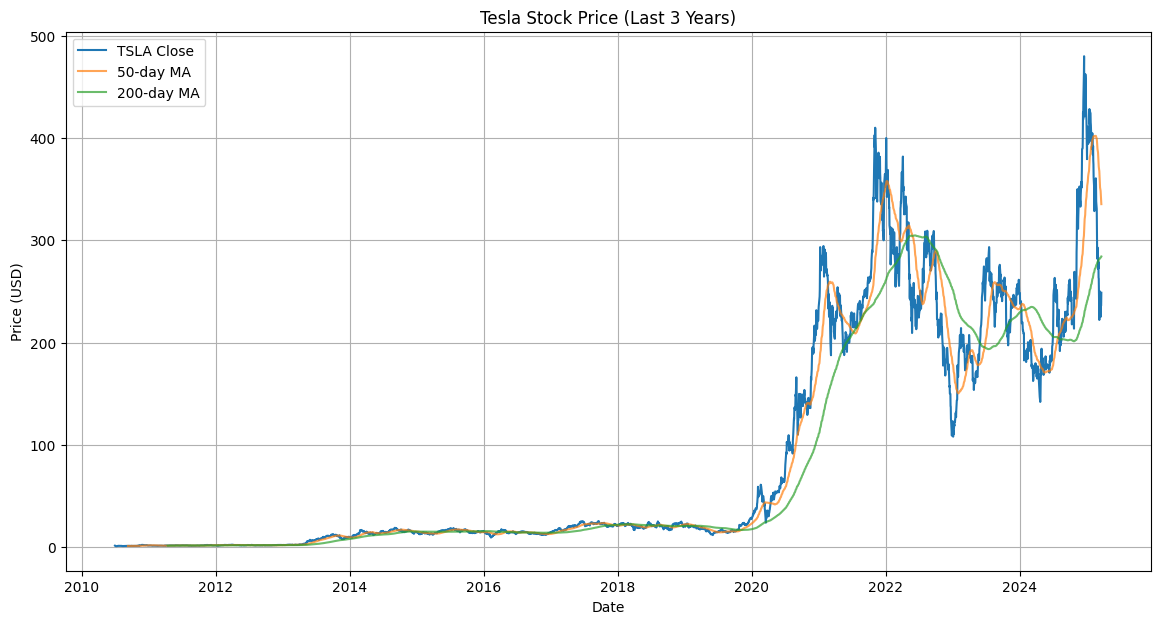

Plot saved as 'tesla_stock_price.png'


In [89]:
plt.figure(figsize=(14, 7))
plt.plot(tesla_data.index, tesla_data['Close'], label='TSLA Close')
plt.plot(tesla_data.index, tesla_data['MA50'], label='50-day MA', alpha=0.7)
plt.plot(tesla_data.index, tesla_data['MA200'], label='200-day MA', alpha=0.7)
plt.title('Tesla Stock Price (Last 3 Years)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('tesla_stock_price.png')
plt.show()

print(f"Plot saved as 'tesla_stock_price.png'")

In [90]:
tesla_data.to_csv('tesla_stock_data.csv')
print(f"Data saved to 'tesla_stock_data.csv'")

Data saved to 'tesla_stock_data.csv'


In [91]:
print("\nBasic Statistics:")
print(tesla_data['Close'].describe())


Basic Statistics:
Ticker         TSLA
count   3705.000000
mean      85.313676
std      111.525337
min        1.053333
25%       12.262667
50%       18.439333
75%      184.130005
max      479.859985
